# Superstore Marketing Campaign — Analysis

## Step 5: Import libraries and load data

In [1]:
# Import all necessary libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

print("Libraries imported successfully")

Libraries imported successfully


In [32]:
# Load data directly with pandas (replaces the MySQL connector + pd.read_sql section)
csv_path = r"D:\Carrier247\Capstone Project\Zip(Final engineered dataset)superstore_cleaned\(Final engineered dataset)superstore_cleaned.csv"  # update this path if your file is located elsewhere

df = pd.read_csv(csv_path)
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,2014-11-05,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,2014-08-04,0,6,...,11,0,34,2,3,1,2,7,1,0


In [33]:
print("Shape:", df.shape)

Shape: (2240, 22)


In [34]:
print("Columns:", df.columns.tolist())

Columns: ['Id', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Response', 'Complain']


In [35]:
# Total row count
print("Total rows:", len(df))

Total rows: 2240


In [36]:
##Check for NULLs in Income
print("Null Income count:", df['Income'].isnull().sum())

Null Income count: 24


In [37]:
# Check distinct Education & Marital_Status
print(df['Education'].drop_duplicates())
print(df['Marital_Status'].drop_duplicates())

0     Graduation
5            PhD
6         Master
54         Basic
Name: Education, dtype: object
0     Divorced
1       Single
2      Married
3     Together
12       Widow
Name: Marital_Status, dtype: object


## Step 6: Data cleaning and EDA

In [38]:
# Cell 2 — Handle missing Income values (median imputation)
print("Missing Income before:", df['Income'].isnull().sum())
df['Income'].fillna(df['Income'].median(), inplace=True)
print("Missing Income after:", df['Income'].isnull().sum())

Missing Income before: 24
Missing Income after: 0


In [39]:
# Cell 3 — Feature Engineering
import datetime

# Age from Year_Birth
current_year = datetime.datetime.now().year
df['Age'] = current_year - df['Year_Birth']

# Tenure in days from Dt_Customer
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['Tenure_Days'] = (pd.Timestamp.today() - df['Dt_Customer']).dt.days

# Total Spend across all product categories
spend_cols = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']
df['Total_Spend'] = df[spend_cols].sum(axis=1)

# Category Breadth — how many categories customer spent on
df['Category_Breadth'] = (df[spend_cols] > 0).sum(axis=1)

# Total Purchases across all channels
purchase_cols = ['NumDealsPurchases','NumWebPurchases',
                 'NumCatalogPurchases','NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# Web-to-Store ratio (avoid division by zero)
df['Web_Store_Ratio'] = df['NumWebPurchases'] / (df['NumStorePurchases'] + 1)

# Family size
df['Family_Size'] = df['Kidhome'] + df['Teenhome']

print(df[['Age','Tenure_Days','Total_Spend','Category_Breadth',
          'Total_Purchases','Family_Size']].describe())

               Age  Tenure_Days  Total_Spend  Category_Breadth  \
count  2240.000000  2240.000000  2240.000000       2240.000000   
mean     57.194196  4777.043304   605.798214          5.429464   
std      11.984069   232.229893   602.249288          0.923335   
min      30.000000  4265.000000     5.000000          2.000000   
25%      49.000000  4605.750000    68.750000          5.000000   
50%      56.000000  4778.000000   396.000000          6.000000   
75%      67.000000  4950.250000  1045.500000          6.000000   
max     133.000000  5328.000000  2525.000000          6.000000   

       Total_Purchases  Family_Size  
count      2240.000000  2240.000000  
mean         14.862054     0.950446  
std           7.677173     0.751803  
min           0.000000     0.000000  
25%           8.000000     0.000000  
50%          15.000000     1.000000  
75%          21.000000     1.000000  
max          44.000000     3.000000  


In [40]:
# Cell 4 — Standardise categoricals
# Consolidate rare Marital_Status values
df['Marital_Status'] = df['Marital_Status'].replace(
    {'Absurd': 'Other', 'Alone': 'Single', 'YOLO': 'Other'}
)
print(df['Marital_Status'].value_counts())
print(df['Education'].value_counts())

Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64
Education
Graduation    1127
Master         573
PhD            486
Basic           54
Name: count, dtype: int64


In [41]:
# Cell 5 — Drop outliers: implausible Age
print("Age range before:", df['Age'].min(), "–", df['Age'].max())
df = df[df['Age'] < 100]
print("Age range after:", df['Age'].min(), "–", df['Age'].max())
print("Shape after outlier removal:", df.shape)

Age range before: 30 – 133
Age range after: 30 – 86
Shape after outlier removal: (2237, 29)


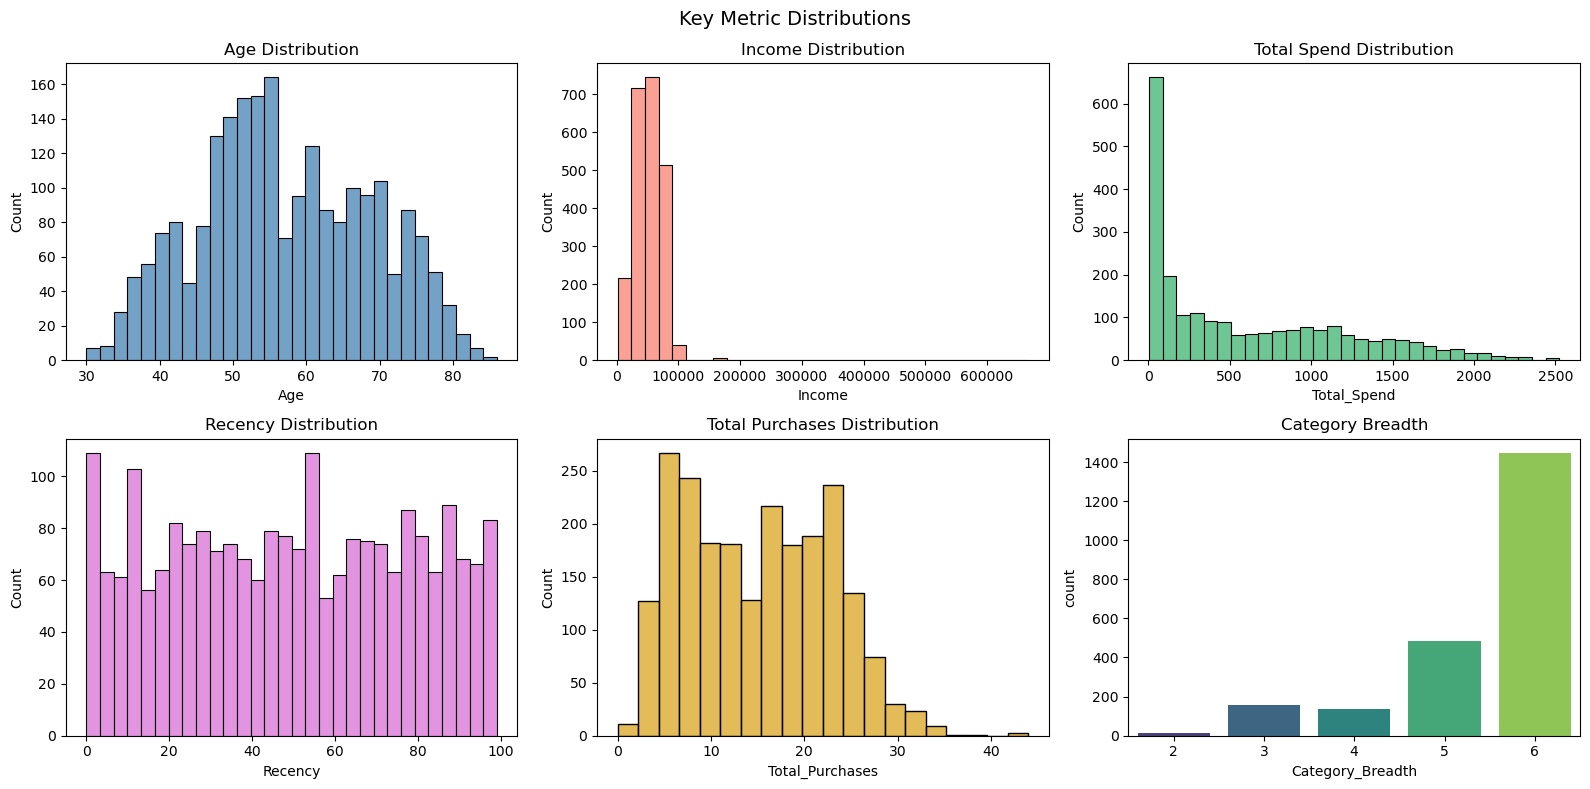

In [42]:
# Cell 6 — Distribution plots
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Key Metric Distributions", fontsize=14)

sns.histplot(df['Age'], bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title("Age Distribution")

sns.histplot(df['Income'], bins=30, ax=axes[0,1], color='salmon')
axes[0,1].set_title("Income Distribution")

sns.histplot(df['Total_Spend'], bins=30, ax=axes[0,2], color='mediumseagreen')
axes[0,2].set_title("Total Spend Distribution")

sns.histplot(df['Recency'], bins=30, ax=axes[1,0], color='orchid')
axes[1,0].set_title("Recency Distribution")

sns.histplot(df['Total_Purchases'], bins=20, ax=axes[1,1], color='goldenrod')
axes[1,1].set_title("Total Purchases Distribution")

sns.countplot(x='Category_Breadth', data=df, ax=axes[1,2], palette='viridis')
axes[1,2].set_title("Category Breadth")

plt.tight_layout()
plt.show()

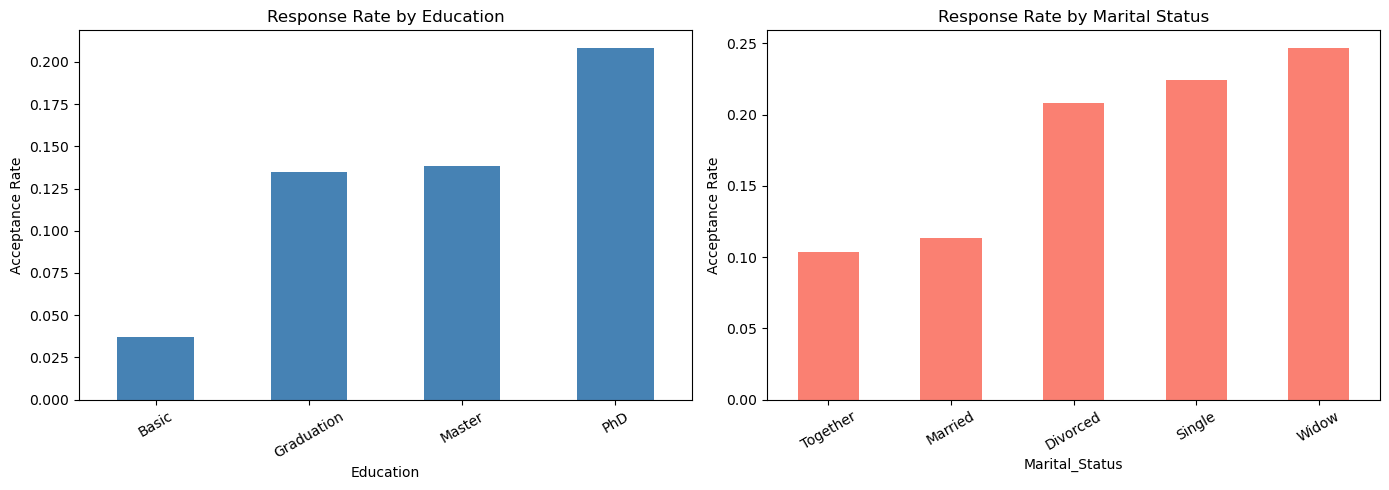

In [43]:
# Cell 7 — Response rate by Education & Marital Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Education')['Response'].mean().sort_values().plot(
    kind='bar', ax=axes[0], color='steelblue', title='Response Rate by Education')
axes[0].set_ylabel("Acceptance Rate")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

df.groupby('Marital_Status')['Response'].mean().sort_values().plot(
    kind='bar', ax=axes[1], color='salmon', title='Response Rate by Marital Status')
axes[1].set_ylabel("Acceptance Rate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

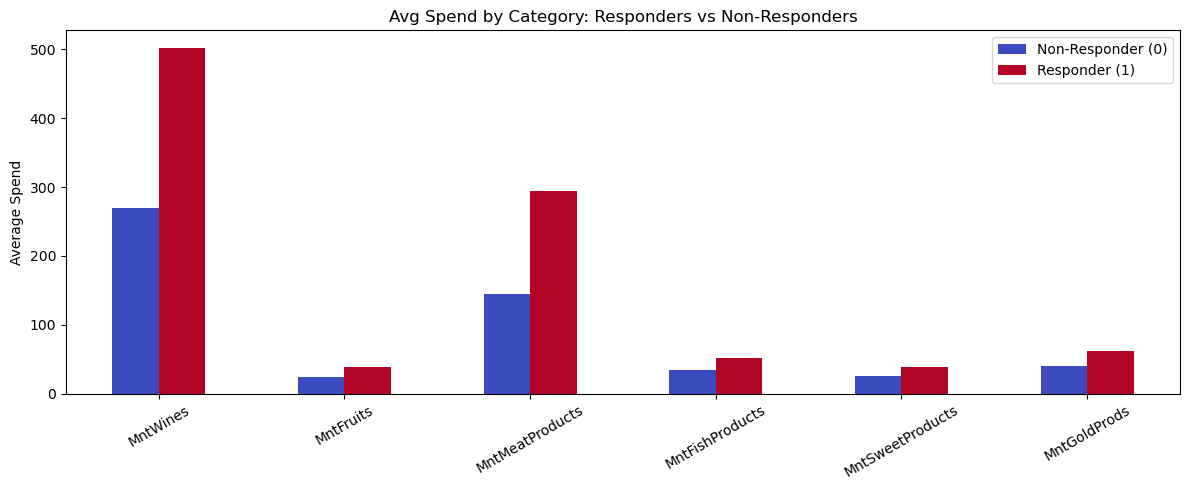

In [44]:
# Cell 8 — Spend by category (Responders vs Non-responders)
spend_means = df.groupby('Response')[spend_cols].mean()
spend_means.T.plot(kind='bar', figsize=(12,5), colormap='coolwarm',
                   title='Avg Spend by Category: Responders vs Non-Responders')
plt.ylabel("Average Spend")
plt.xticks(rotation=30)
plt.legend(['Non-Responder (0)', 'Responder (1)'])
plt.tight_layout()
plt.show()

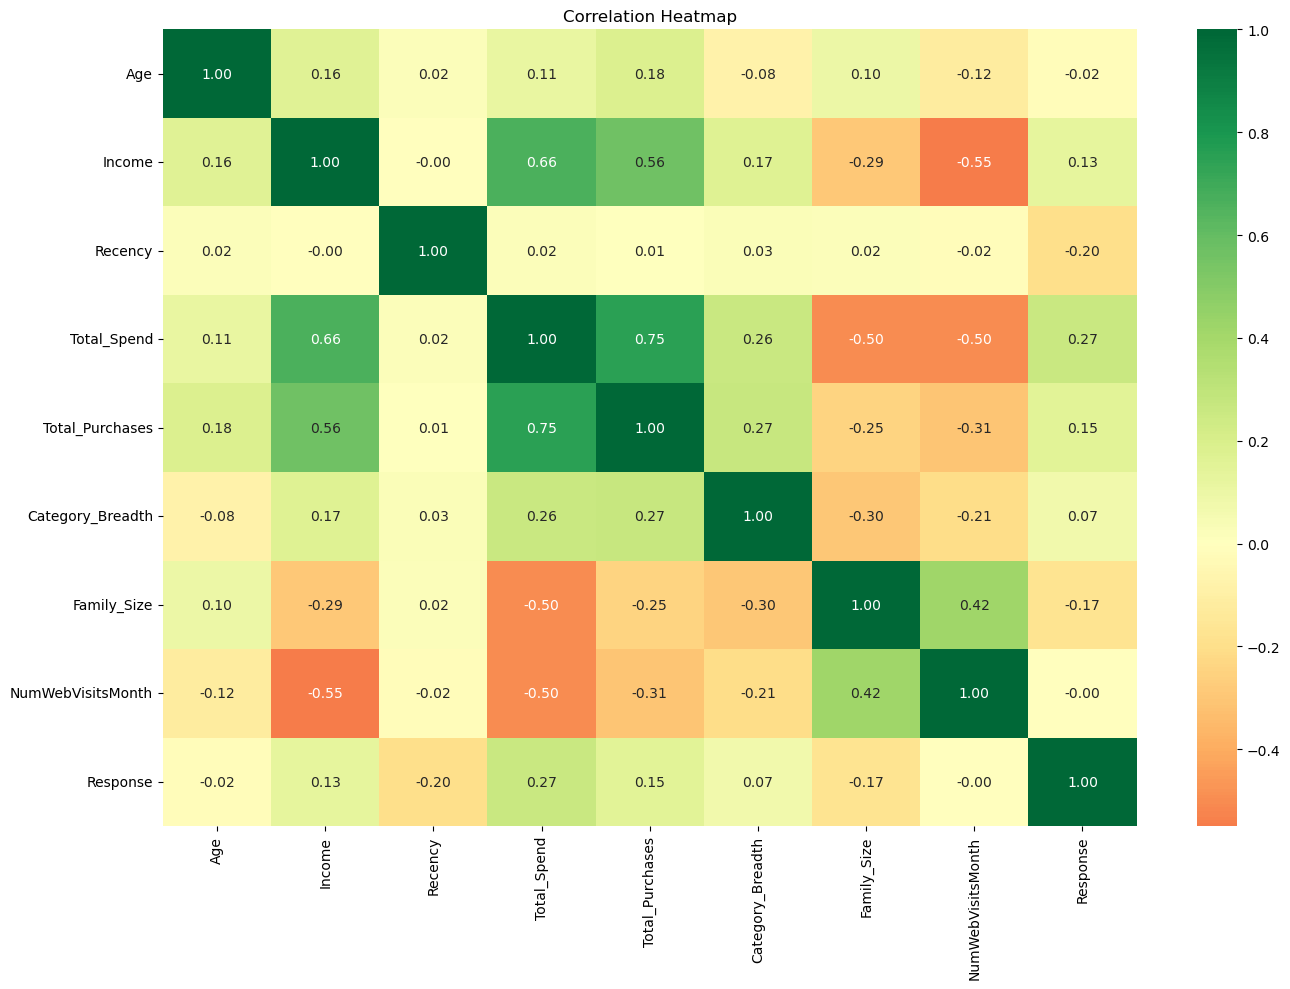

In [45]:
# Cell 9 — Correlation heatmap
plt.figure(figsize=(14,10))
numeric_cols = ['Age','Income','Recency','Total_Spend','Total_Purchases',
                'Category_Breadth','Family_Size','NumWebVisitsMonth','Response']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Channel EDA

          NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
Response                                                            
0                3.914346             2.392013           5.741461   
1                5.071856             4.203593           6.095808   

          NumDealsPurchases  NumWebVisitsMonth  
Response                                        
0                  2.325276           5.323699  
1                  2.335329           5.293413  


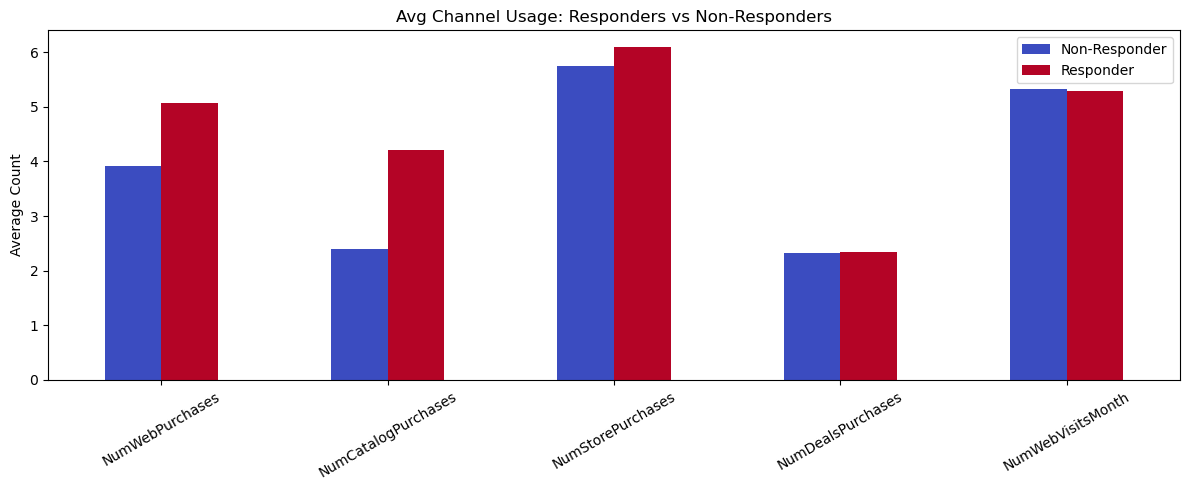

In [46]:
# Channel Performance Analysis
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases',
                'NumStorePurchases', 'NumDealsPurchases', 'NumWebVisitsMonth']

# Average channel usage: Responders vs Non-responders
channel_means = df.groupby('Response')[channel_cols].mean()
print(channel_means)

channel_means.T.plot(kind='bar', figsize=(12,5), colormap='coolwarm',
                     title='Avg Channel Usage: Responders vs Non-Responders')
plt.ylabel("Average Count")
plt.xticks(rotation=30)
plt.legend(['Non-Responder','Responder'])
plt.tight_layout()
plt.show()

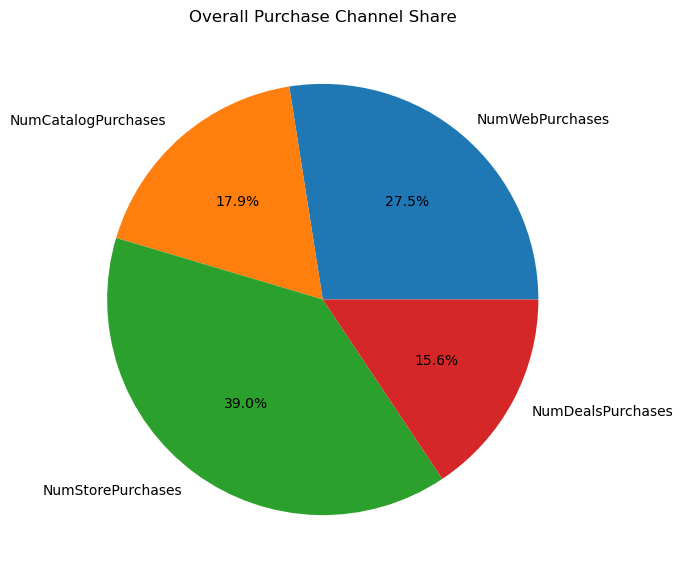

In [47]:
# Channel contribution to Total Purchases
channel_totals = df[['NumWebPurchases','NumCatalogPurchases',
                      'NumStorePurchases','NumDealsPurchases']].sum()
channel_totals.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7),
                    title='Overall Purchase Channel Share')
plt.ylabel("")
plt.show()

## Step 7 — Statistical Analysis

In [48]:
# Cell 1 — Imports
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Imports done!")

Imports done!


In [49]:
# Cell 2 — T-test: Income & Total_Spend by Response
responders = df[df['Response'] == 1]
non_responders = df[df['Response'] == 0]

for col in ['Income', 'Total_Spend', 'Age', 'Recency']:
    t_stat, p_val = stats.ttest_ind(responders[col], non_responders[col])
    sig = "✅ Significant" if p_val < 0.05 else "❌ Not Significant"
    print(f"{col}: t={t_stat:.3f}, p={p_val:.4f} → {sig}")
    print(f"   Responders mean: {responders[col].mean():.2f} | Non-responders mean: {non_responders[col].mean():.2f}\n")

Income: t=6.350, p=0.0000 → ✅ Significant
   Responders mean: 60183.24 | Non-responders mean: 50831.06

Total_Spend: t=13.031, p=0.0000 → ✅ Significant
   Responders mean: 987.39 | Non-responders mean: 538.76

Age: t=-0.871, p=0.3838 → ❌ Not Significant
   Responders mean: 56.58 | Non-responders mean: 57.19

Recency: t=-9.578, p=0.0000 → ✅ Significant
   Responders mean: 35.38 | Non-responders mean: 51.51



In [50]:
# Cell 3 — Chi-square: Categorical vs Response
from scipy.stats import chi2_contingency

for col in ['Education', 'Marital_Status']:
    ct = pd.crosstab(df[col], df['Response'])
    chi2, p, dof, expected = chi2_contingency(ct)
    sig = "✅ Significant" if p < 0.05 else "❌ Not Significant"
    print(f"{col}: chi2={chi2:.3f}, p={p:.4f}, dof={dof} → {sig}\n")

Education: chi2=21.012, p=0.0001, dof=3 → ✅ Significant

Marital_Status: chi2=51.755, p=0.0000, dof=4 → ✅ Significant



In [51]:
# Cell 4 — ANOVA: Total_Spend across Education levels
groups = [grp['Total_Spend'].values for _, grp in df.groupby('Education')]
f_stat, p_val = stats.f_oneway(*groups)
sig = "✅ Significant" if p_val < 0.05 else "❌ Not Significant"
print(f"ANOVA — Total_Spend by Education: F={f_stat:.3f}, p={p_val:.4f} → {sig}")

# Also do Income across Marital_Status
groups2 = [grp['Income'].values for _, grp in df.groupby('Marital_Status')]
f_stat2, p_val2 = stats.f_oneway(*groups2)
sig2 = "✅ Significant" if p_val2 < 0.05 else "❌ Not Significant"
print(f"ANOVA — Income by Marital_Status: F={f_stat2:.3f}, p={p_val2:.4f} → {sig2}")

ANOVA — Total_Spend by Education: F=16.602, p=0.0000 → ✅ Significant
ANOVA — Income by Marital_Status: F=1.158, p=0.3274 → ❌ Not Significant


In [52]:
# Cell 5 — Prepare features for modelling
model_df = df.copy()

# Encode categoricals
le = LabelEncoder()
model_df['Education_enc'] = le.fit_transform(model_df['Education'])
model_df['Marital_enc'] = le.fit_transform(model_df['Marital_Status'])

features = ['Age', 'Income', 'Recency', 'Total_Spend', 'Total_Purchases',
            'Category_Breadth', 'Family_Size', 'NumWebPurchases',
            'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases',
            'NumWebVisitsMonth', 'Web_Store_Ratio', 'Tenure_Days',
            'Education_enc', 'Marital_enc']

X = model_df[features]
y = model_df['Response']

print("Class distribution:\n", y.value_counts())
print("\nFeature set shape:", X.shape)

Class distribution:
 Response
0    1903
1     334
Name: count, dtype: int64

Feature set shape: (2237, 16)


In [53]:
# Cell 6 — Train/Test Split + Logistic Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       381
           1       0.68      0.28      0.40        67

    accuracy                           0.87       448
   macro avg       0.78      0.63      0.66       448
weighted avg       0.85      0.87      0.85       448

ROC-AUC: 0.8378


In [54]:
# Cell 7 — Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       381
           1       0.67      0.27      0.38        67

    accuracy                           0.87       448
   macro avg       0.78      0.62      0.66       448
weighted avg       0.85      0.87      0.85       448

ROC-AUC: 0.8879


In [55]:
# Cell 7b — Improved model with SMOTE
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("After SMOTE:", y_resampled.value_counts())

rf_smote = RandomForestClassifier(n_estimators=200, random_state=42)
rf_smote.fit(X_resampled, y_resampled)
y_pred_smote = rf_smote.predict(X_test)

print("=== Random Forest + SMOTE ===")
print(classification_report(y_test, y_pred_smote))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_smote.predict_proba(X_test)[:,1]):.4f}")

After SMOTE: Response
0    1522
1    1522
Name: count, dtype: int64
=== Random Forest + SMOTE ===
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       381
           1       0.52      0.51      0.51        67

    accuracy                           0.85       448
   macro avg       0.71      0.71      0.71       448
weighted avg       0.85      0.85      0.85       448

ROC-AUC: 0.8907


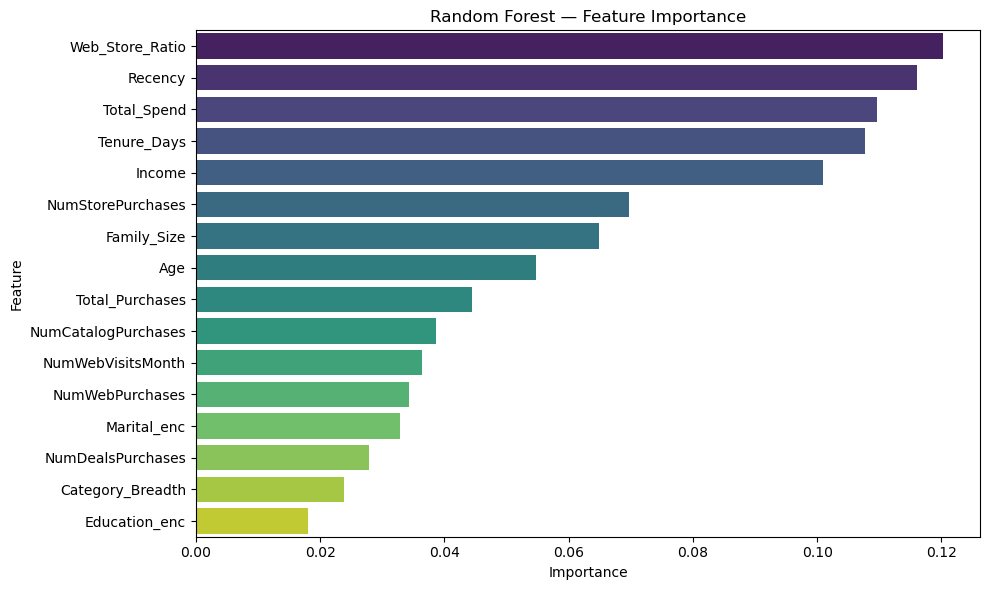

                Feature  Importance
12      Web_Store_Ratio    0.120190
2               Recency    0.116079
3           Total_Spend    0.109650
13          Tenure_Days    0.107760
1                Income    0.100887
9     NumStorePurchases    0.069759
6           Family_Size    0.064860
0                   Age    0.054663
4       Total_Purchases    0.044405
8   NumCatalogPurchases    0.038670
11    NumWebVisitsMonth    0.036342
7       NumWebPurchases    0.034224
15          Marital_enc    0.032835
10    NumDealsPurchases    0.027869
5      Category_Breadth    0.023801
14        Education_enc    0.018007


In [56]:
# Cell 8 — Feature Importance (Random Forest)
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_smote.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

print(importance_df)

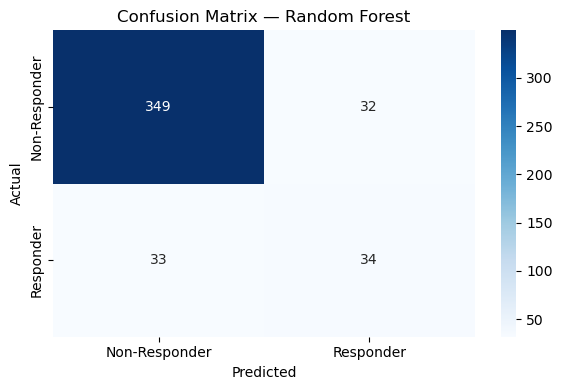

In [57]:
# Cell 9 — Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Responder','Responder'],
            yticklabels=['Non-Responder','Responder'])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [58]:
# Run this before closing
df.to_csv('superstore_final.csv', index=False)
print("Saved!")

Saved!
